# Retail Sales – EDA & Hypothesis Testing

**Dataset** : `Testing.xlsx`  
**Shape** : 188,340 rows × 10 columns  
**Date range** : Jan 2018 – May 2019  
**Columns** : `ID`, `Store_id`, `Store_Type`, `Location_Type`, `Region_Code`, `Date`, `Holiday`, `Discount`, `#Order`, `Sales`

---

In [19]:
# ─── 0. Imports ───────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import gdown
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from itertools import combinations
from scipy import stats
from scipy.stats import (ttest_ind, f_oneway, kruskal,
                          pearsonr, spearmanr, shapiro, levene, zscore)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

ALPHA = 0.05
PALETTE = {'Yes': '#2196F3', 'No': '#FF7043',
           'S1': '#4CAF50', 'S2': '#FFC107', 'S3': '#9C27B0', 'S4': '#F44336'}

def test_result(name, stat, p, alpha=ALPHA):
    decision = '✔ REJECT H₀' if p < alpha else '✘ FAIL TO REJECT H₀'
    print(f'  Test      : {name}')
    print(f'  Statistic : {stat:.4f}')
    print(f'  p-value   : {p:.2e}')
    print(f'  Decision  : {decision}  (α={alpha})')

print('Setup complete ✔')

Setup complete ✔


---
## 1 · Load & Inspect Data

In [20]:
url = "https://drive.google.com/uc?id=1ditFn_74EOsGnblf2nXr-Vx-I1mrCG42"
output = "dataset.csv"

gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1ditFn_74EOsGnblf2nXr-Vx-I1mrCG42
To: c:\Users\YADAV\Downloads\dataset.csv
100%|██████████| 9.33M/9.33M [00:01<00:00, 7.88MB/s]


'dataset.csv'

In [21]:
df = pd.read_csv('dataset.csv')

In [22]:
df = pd.read_csv('dataset.csv', parse_dates=['Date'])

# Derived columns
df['Year']         = df['Date'].dt.year
df['Month']        = df['Date'].dt.month
df['MonthName']    = df['Date'].dt.strftime('%b')
df['Quarter']      = df['Date'].dt.quarter
df['Discount_bin'] = (df['Discount'] == 'Yes').astype(int)
df['Holiday_lbl']  = df['Holiday'].map({1: 'Holiday', 0: 'Non-Holiday'})

print(f'Shape : {df.shape}')
df.head(3)

Shape : (188340, 16)


,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,#Order,Sales,Year,Month,MonthName,Quarter,Discount_bin,Holiday_lbl
0,T1000001,1,S1,L3,R1,2018-01-01,1,Yes,9,7011.84,2018,1,Jan,1,1,Holiday
1,T1000002,253,S4,L2,R1,2018-01-01,1,Yes,60,51789.12,2018,1,Jan,1,1,Holiday
2,T1000003,252,S3,L2,R1,2018-01-01,1,Yes,42,36868.20,2018,1,Jan,1,1,Holiday


In [23]:
print(df.columns.tolist())

['ID', 'Store_id', 'Store_Type', 'Location_Type', 'Region_Code', 'Date', 'Holiday', 'Discount', '#Order', 'Sales', 'Year', 'Month', 'MonthName', 'Quarter', 'Discount_bin', 'Holiday_lbl']


In [24]:
print('─── dtypes ───')
print(df.dtypes)
print()
print('─── Missing values ───')
print(df.isnull().sum())
print()
print('─── Numeric summary ───')
df[['Sales','#Order']].describe().round(2)

─── dtypes ───
ID                       object
Store_id                  int64
Store_Type               object
Location_Type            object
Region_Code              object
Date             datetime64[ns]
Holiday                   int64
Discount                 object
#Order                    int64
Sales                   float64
Year                      int32
Month                     int32
MonthName                object
Quarter                   int32
Discount_bin              int64
Holiday_lbl              object
dtype: object

─── Missing values ───
ID               0
Store_id         0
Store_Type       0
Location_Type    0
Region_Code      0
Date             0
Holiday          0
Discount         0
#Order           0
Sales            0
Year             0
Month            0
MonthName        0
Quarter          0
Discount_bin     0
Holiday_lbl      0
dtype: int64

─── Numeric summary ───


,Sales,#Order
count,188340.00,188340.00
mean,42784.33,68.21
std,18456.71,30.47
min,0.00,0.00
25%,30426.00,48.00
50%,39678.00,63.00
75%,51909.00,82.00
max,247215.00,371.00


In [25]:
print('─── Categorical unique values ───')
for col in ['Store_Type','Location_Type','Region_Code','Discount','Holiday']:
    print(f'  {col:15s}: {sorted(df[col].unique().tolist())}')

─── Categorical unique values ───
  Store_Type     : ['S1', 'S2', 'S3', 'S4']
  Location_Type  : ['L1', 'L2', 'L3', 'L4', 'L5']
  Region_Code    : ['R1', 'R2', 'R3', 'R4']
  Discount       : ['No', 'Yes']
  Holiday        : [0, 1]


---
## 2 · Univariate Analysis

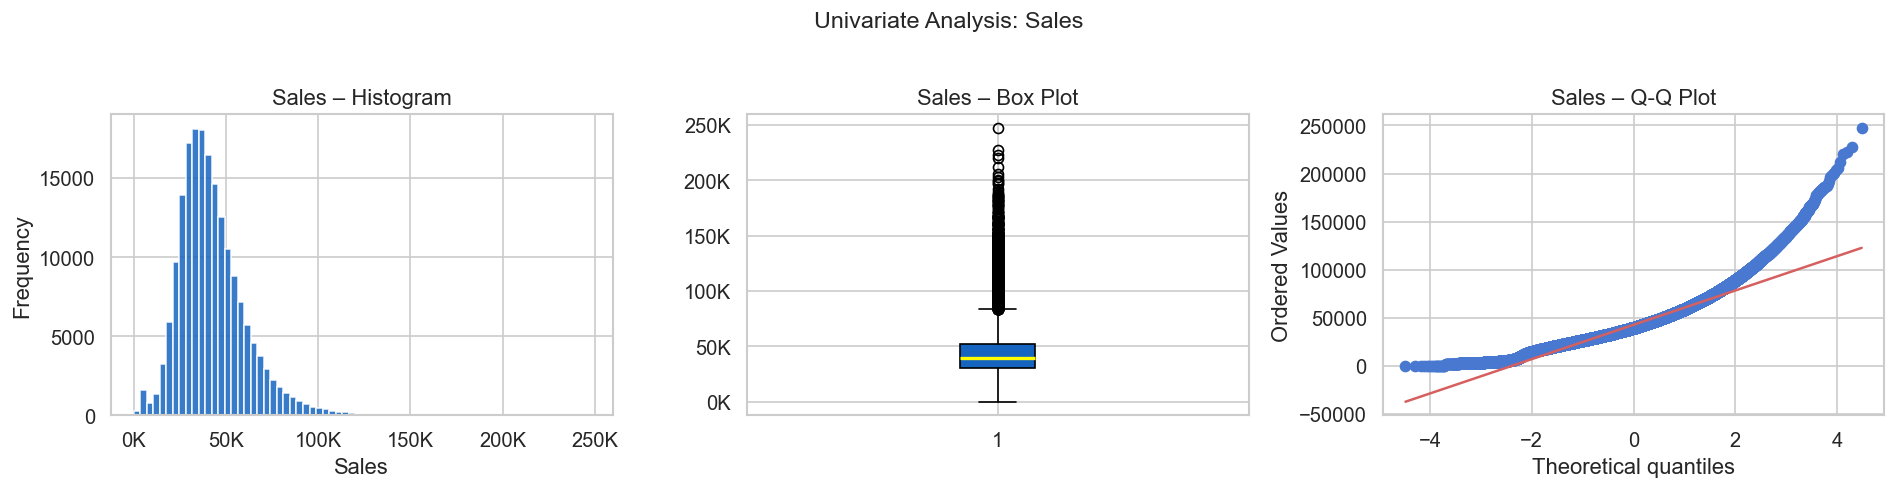

Mean   :    42,784.33
Median :    39,678.00
Std    :    18,456.71
Skew   :       1.2488
Kurt   :       3.4854


In [26]:
# ── 2A. Sales distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram
axes[0].hist(df['Sales'], bins=70, color='#1565C0', edgecolor='white', alpha=0.85)
axes[0].set_title('Sales – Histogram')
axes[0].set_xlabel('Sales'); axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

# Box plot
axes[1].boxplot(df['Sales'], patch_artist=True,
                boxprops=dict(facecolor='#1565C0'),
                medianprops=dict(color='yellow', linewidth=2))
axes[1].set_title('Sales – Box Plot')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

# QQ plot
stats.probplot(df['Sales'], dist='norm', plot=axes[2])
axes[2].set_title('Sales – Q-Q Plot')

plt.suptitle('Univariate Analysis: Sales', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

print(f"Mean   : {df['Sales'].mean():>12,.2f}")
print(f"Median : {df['Sales'].median():>12,.2f}")
print(f"Std    : {df['Sales'].std():>12,.2f}")
print(f"Skew   : {df['Sales'].skew():>12.4f}")
print(f"Kurt   : {df['Sales'].kurtosis():>12.4f}")

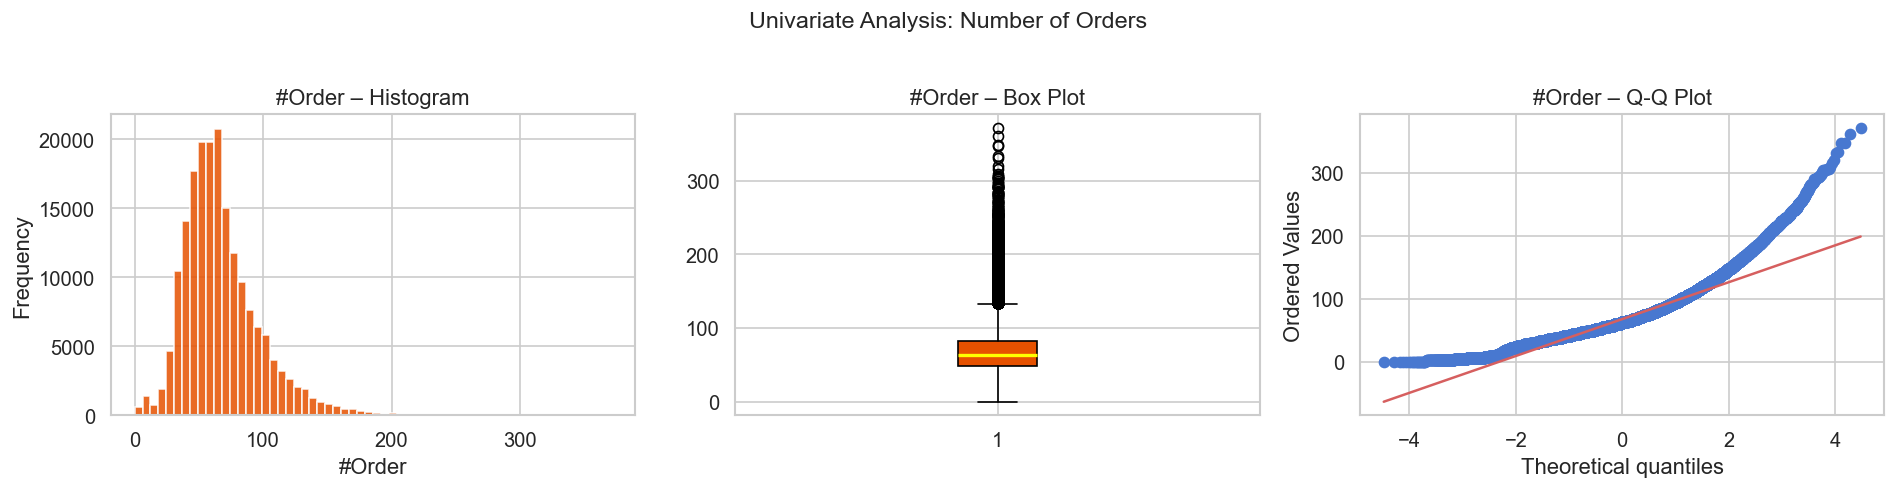

Mean   :    68.21
Median :       63
Std    :    30.47
Skew   :   1.3729


In [27]:
# ── 2B. #Order distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['#Order'], bins=60, color='#E65100', edgecolor='white', alpha=0.85)
axes[0].set_title('#Order – Histogram')
axes[0].set_xlabel('#Order'); axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['#Order'], patch_artist=True,
                boxprops=dict(facecolor='#E65100'),
                medianprops=dict(color='yellow', linewidth=2))
axes[1].set_title('#Order – Box Plot')

stats.probplot(df['#Order'], dist='norm', plot=axes[2])
axes[2].set_title('#Order – Q-Q Plot')

plt.suptitle('Univariate Analysis: Number of Orders', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

print(f"Mean   : {df['#Order'].mean():>8.2f}")
print(f"Median : {df['#Order'].median():>8.0f}")
print(f"Std    : {df['#Order'].std():>8.2f}")
print(f"Skew   : {df['#Order'].skew():>8.4f}")

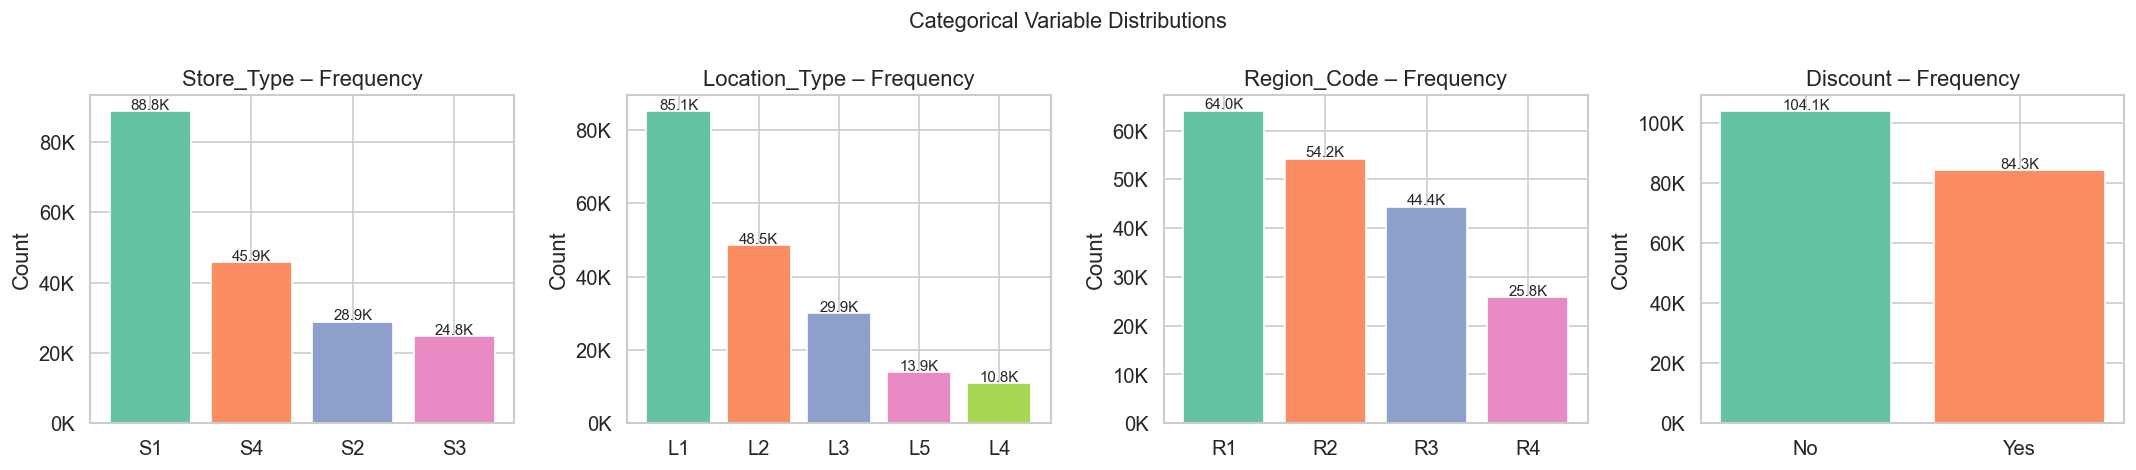

In [28]:
# ── 2C. Categorical distributions ─────────────────────────────────────────────
cat_cols = ['Store_Type', 'Location_Type', 'Region_Code', 'Discount']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=sns.color_palette('Set2', len(counts)), edgecolor='white')
    ax.set_title(f'{col} – Frequency')
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
    for p, v in zip(bars, counts.values):
        ax.text(p.get_x()+p.get_width()/2, p.get_height()+500,
                f'{v/1000:.1f}K', ha='center', fontsize=9)

plt.suptitle('Categorical Variable Distributions', fontsize=13)
plt.tight_layout(); plt.show()

---
## 3 · Bivariate Analysis

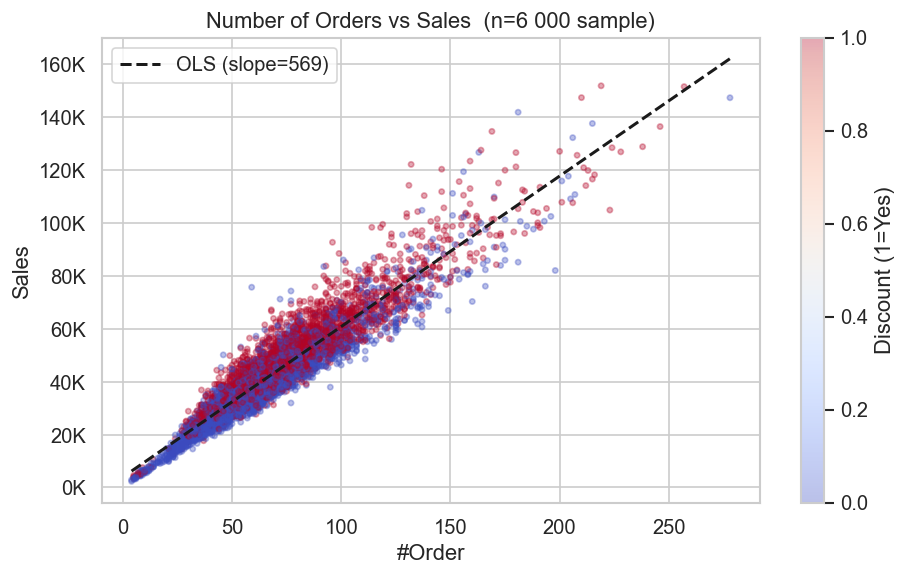

In [29]:
# ── 3A. Scatter: #Order vs Sales ──────────────────────────────────────────────
sample = df.sample(6000, random_state=42)

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(sample['#Order'], sample['Sales'],
                c=sample['Discount_bin'], cmap='coolwarm', alpha=0.35, s=10)
plt.colorbar(sc, ax=ax, label='Discount (1=Yes)')
m, b = np.polyfit(sample['#Order'], sample['Sales'], 1)
xl = np.linspace(sample['#Order'].min(), sample['#Order'].max(), 200)
ax.plot(xl, m*xl+b, 'k--', lw=1.8, label=f'OLS (slope={m:.0f})')
ax.set_xlabel('#Order'); ax.set_ylabel('Sales')
ax.set_title('Number of Orders vs Sales  (n=6 000 sample)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.legend()
plt.tight_layout(); plt.show()

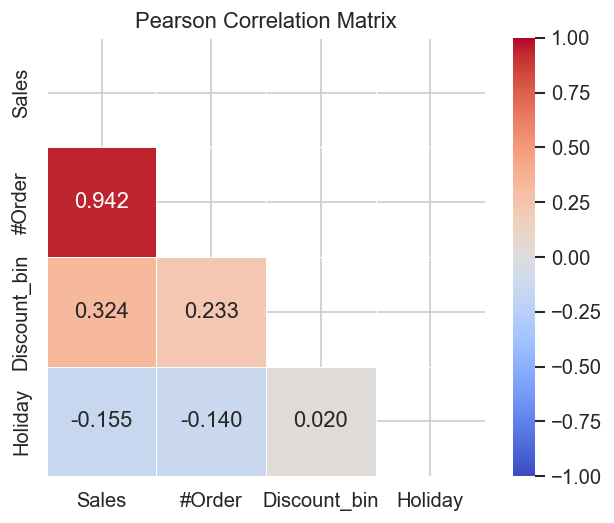

In [30]:
# ── 3B. Pearson correlation matrix ────────────────────────────────────────────
num_df = df[['Sales','#Order','Discount_bin','Holiday']]
corr   = num_df.corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f',
            cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Pearson Correlation Matrix')
plt.tight_layout(); plt.show()

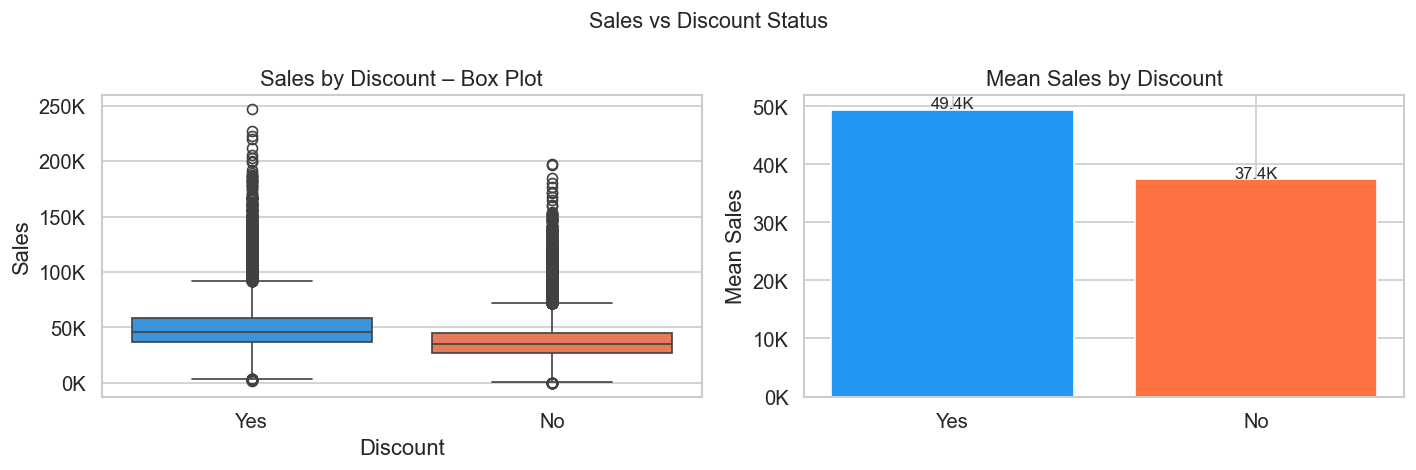

In [31]:
# ── 3C. Sales by Discount ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x='Discount', y='Sales', order=['Yes','No'],
            palette=PALETTE, ax=axes[0])
axes[0].set_title('Sales by Discount – Box Plot')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

means = df.groupby('Discount')['Sales'].mean().reindex(['Yes','No'])
bars  = axes[1].bar(means.index, means.values, color=[PALETTE['Yes'], PALETTE['No']], edgecolor='white')
axes[1].set_title('Mean Sales by Discount')
axes[1].set_ylabel('Mean Sales')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
for p in bars:
    axes[1].text(p.get_x()+p.get_width()/2, p.get_height()+200,
                 f'{p.get_height()/1000:.1f}K', ha='center', fontsize=10)

plt.suptitle('Sales vs Discount Status', fontsize=13)
plt.tight_layout(); plt.show()

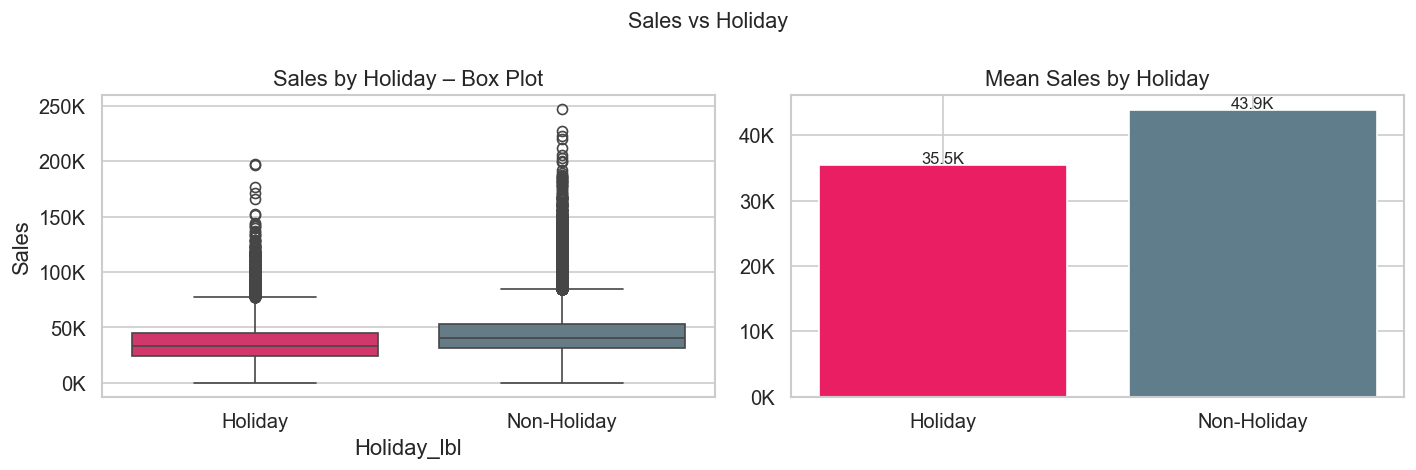

In [32]:
# ── 3D. Sales by Holiday ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

hpal = {'Holiday':'#E91E63', 'Non-Holiday':'#607D8B'}
sns.boxplot(data=df, x='Holiday_lbl', y='Sales',
            order=['Holiday','Non-Holiday'], palette=hpal, ax=axes[0])
axes[0].set_title('Sales by Holiday – Box Plot')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

hmeans = df.groupby('Holiday_lbl')['Sales'].mean().reindex(['Holiday','Non-Holiday'])
bars = axes[1].bar(hmeans.index, hmeans.values,
                   color=[hpal['Holiday'], hpal['Non-Holiday']], edgecolor='white')
axes[1].set_title('Mean Sales by Holiday')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
for p in bars:
    axes[1].text(p.get_x()+p.get_width()/2, p.get_height()+200,
                 f'{p.get_height()/1000:.1f}K', ha='center', fontsize=10)

plt.suptitle('Sales vs Holiday', fontsize=13)
plt.tight_layout(); plt.show()

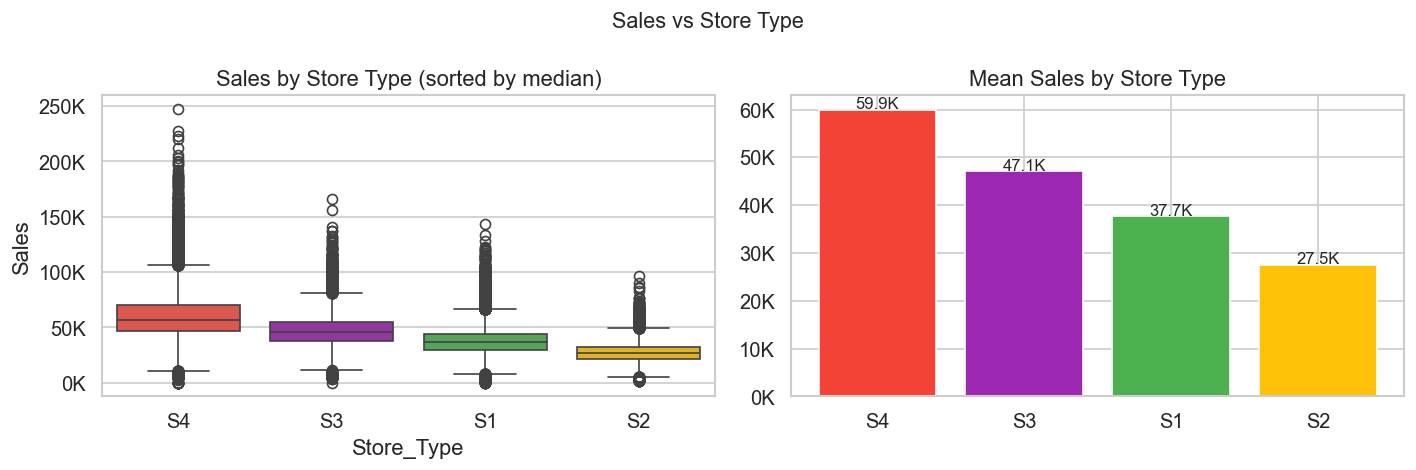

In [33]:
# ── 3E. Sales by Store Type ───────────────────────────────────────────────────
order_st = df.groupby('Store_Type')['Sales'].median().sort_values(ascending=False).index
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x='Store_Type', y='Sales', order=order_st,
            palette=PALETTE, ax=axes[0])
axes[0].set_title('Sales by Store Type (sorted by median)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

st_means = df.groupby('Store_Type')['Sales'].mean().reindex(order_st)
bars = axes[1].bar(st_means.index, st_means.values,
                   color=[PALETTE[k] for k in order_st], edgecolor='white')
axes[1].set_title('Mean Sales by Store Type')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
for p in bars:
    axes[1].text(p.get_x()+p.get_width()/2, p.get_height()+200,
                 f'{p.get_height()/1000:.1f}K', ha='center', fontsize=10)

plt.suptitle('Sales vs Store Type', fontsize=13)
plt.tight_layout(); plt.show()

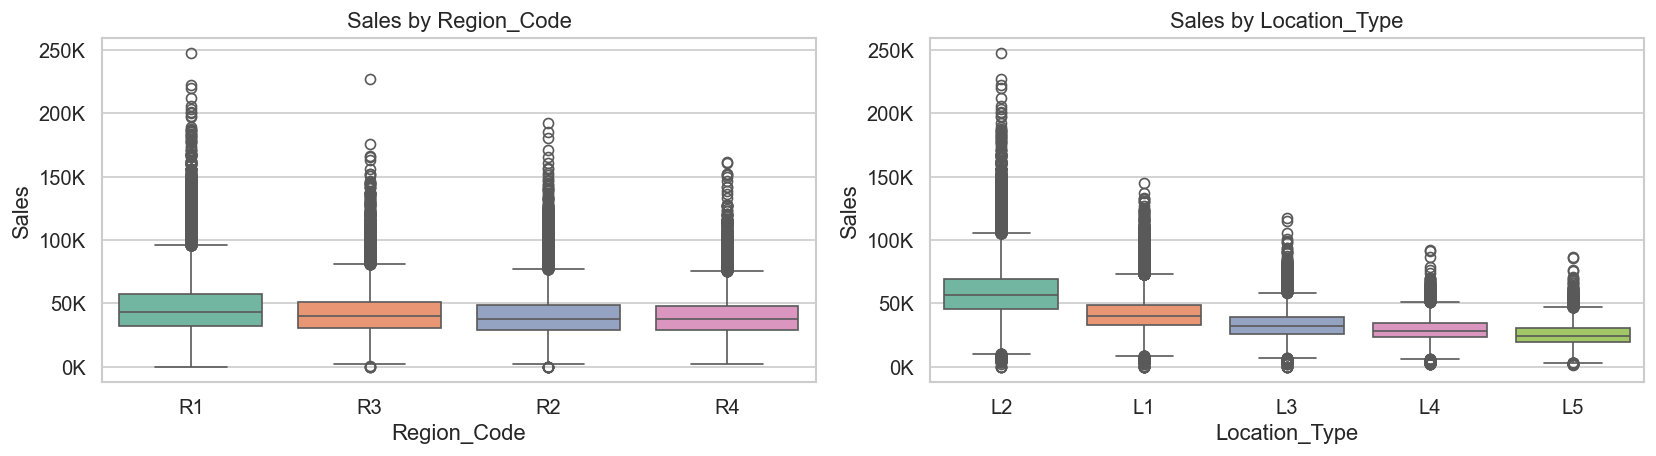

In [34]:
# ── 3F. Sales by Region & Location Type ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col in zip(axes, ['Region_Code','Location_Type']):
    ord_c = df.groupby(col)['Sales'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='Sales', order=ord_c, palette='Set2', ax=ax)
    ax.set_title(f'Sales by {col}')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

plt.tight_layout(); plt.show()

---
## 4 · Time Series Analysis

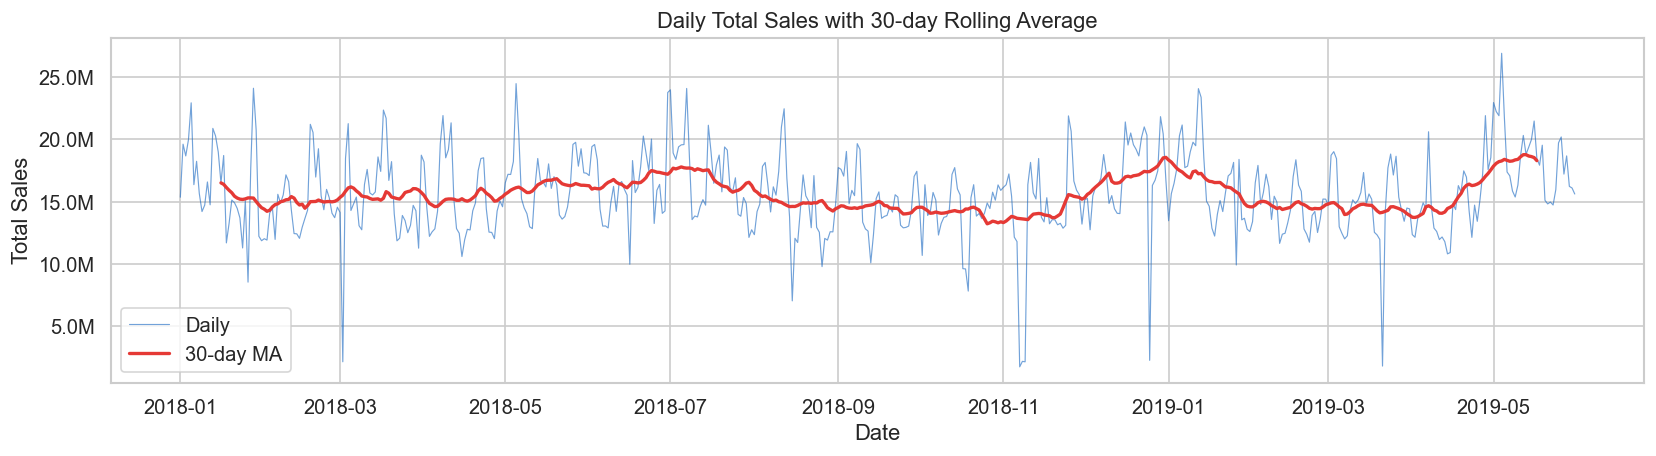

In [35]:
# ── 4A. Daily total sales + 30-day rolling average ────────────────────────────
daily = df.groupby('Date')['Sales'].sum().reset_index()
daily['MA30'] = daily['Sales'].rolling(30, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily['Date'], daily['Sales'], lw=0.7, color='#1565C0', alpha=0.6, label='Daily')
ax.plot(daily['Date'], daily['MA30'],  lw=2,   color='#E53935', label='30-day MA')
ax.set_title('Daily Total Sales with 30-day Rolling Average')
ax.set_xlabel('Date'); ax.set_ylabel('Total Sales')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
ax.legend()
plt.tight_layout(); plt.show()

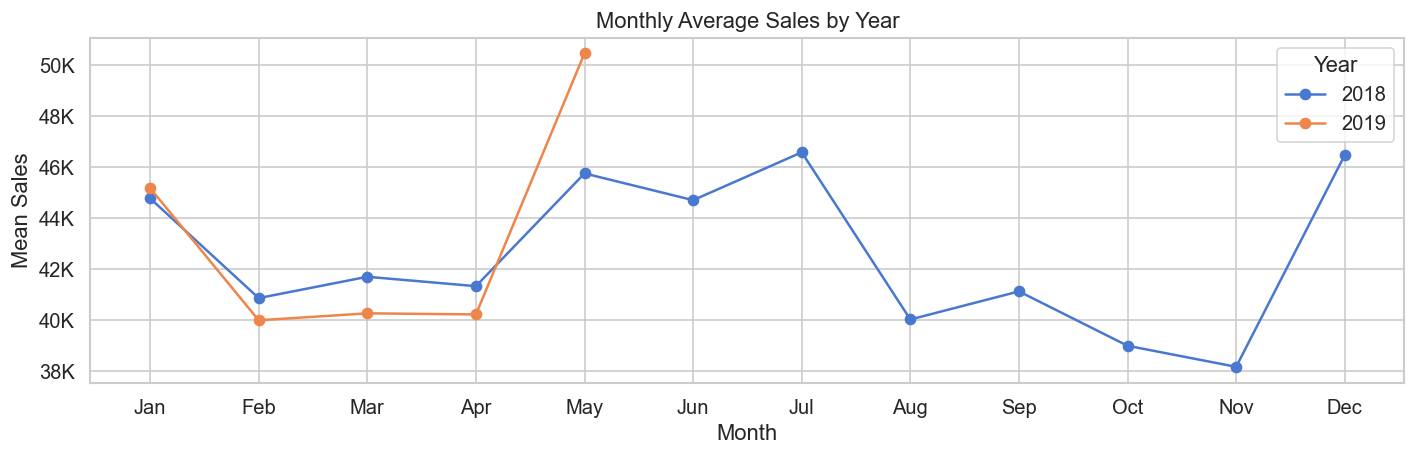

In [36]:
# ── 4B. Monthly average sales by year ─────────────────────────────────────────
monthly = (df.groupby(['Year','Month','MonthName'])['Sales']
             .mean().reset_index().sort_values(['Year','Month']))

fig, ax = plt.subplots(figsize=(12, 4))
for yr, grp in monthly.groupby('Year'):
    ax.plot(grp['MonthName'], grp['Sales'], marker='o', label=str(yr))
ax.set_title('Monthly Average Sales by Year')
ax.set_xlabel('Month'); ax.set_ylabel('Mean Sales')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.legend(title='Year')
plt.tight_layout(); plt.show()

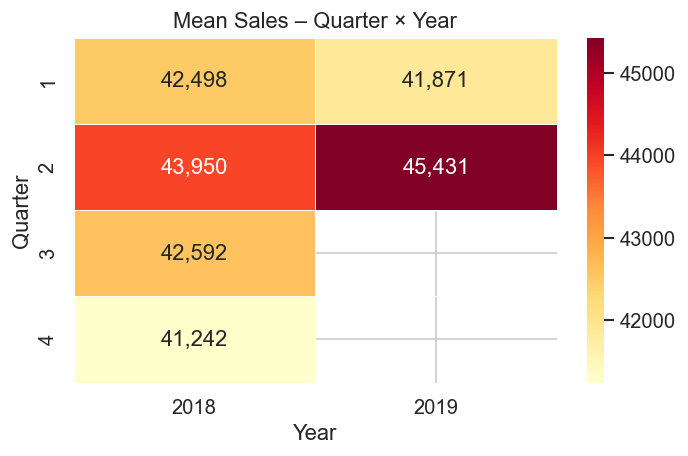

In [37]:
# ── 4C. Quarterly heatmap ─────────────────────────────────────────────────────
heat = df.pivot_table(values='Sales', index='Quarter', columns='Year', aggfunc='mean')

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(heat, annot=True, fmt=',.0f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Mean Sales – Quarter × Year')
plt.tight_layout(); plt.show()

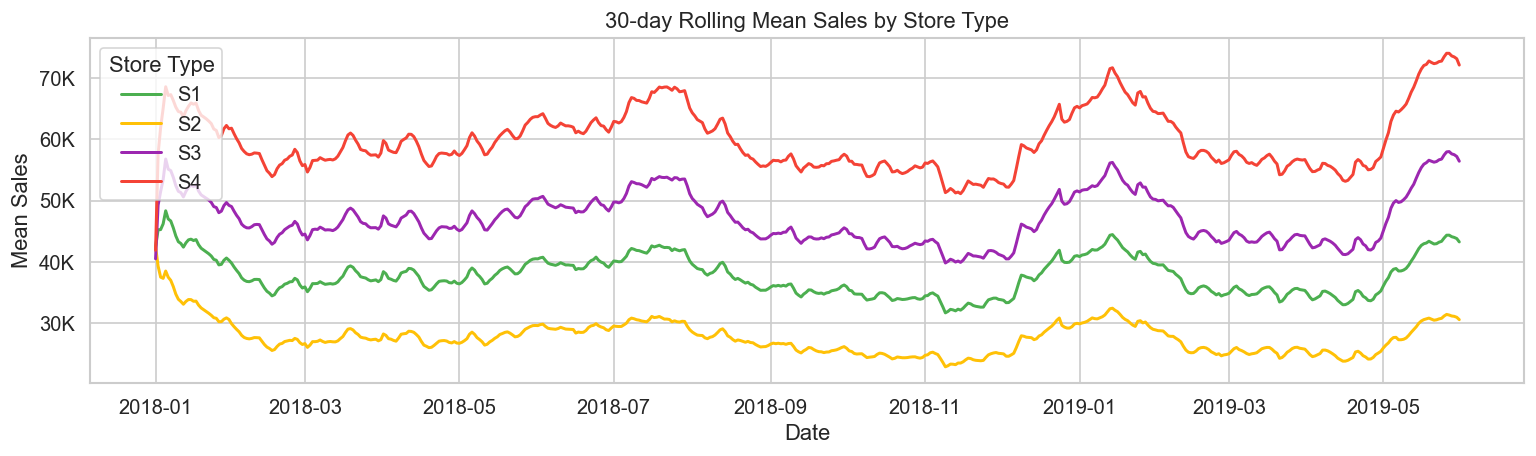

In [38]:
# ── 4D. Sales by Store Type over time ────────────────────────────────────────
ts_type = (df.groupby(['Date','Store_Type'])['Sales']
             .mean().reset_index())

fig, ax = plt.subplots(figsize=(13, 4))
for st, grp in ts_type.groupby('Store_Type'):
    roll = grp.set_index('Date')['Sales'].rolling('30D').mean()
    ax.plot(roll.index, roll.values, lw=1.8, label=st, color=PALETTE[st])
ax.set_title('30-day Rolling Mean Sales by Store Type')
ax.set_xlabel('Date'); ax.set_ylabel('Mean Sales')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.legend(title='Store Type')
plt.tight_layout(); plt.show()

---
## 5 · Outlier Detection

In [39]:
print('─── IQR method ───')
for col in ['Sales','#Order']:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f'  {col:8s} | IQR={IQR:,.0f} | bounds=[{lo:,.0f}, {hi:,.0f}]'
          f' | outliers={n_out:,} ({100*n_out/len(df):.2f}%)')

print()
print('─── Z-score method (|Z|>3) ───')
for col in ['Sales','#Order']:
    z = np.abs(zscore(df[col]))
    n_out = (z > 3).sum()
    print(f'  {col:8s} | outliers={n_out:,} ({100*n_out/len(df):.2f}%)')

─── IQR method ───
  Sales    | IQR=21,483 | bounds=[-1,798, 84,134] | outliers=5,843 (3.10%)
  #Order   | IQR=34 | bounds=[-3, 133] | outliers=7,089 (3.76%)

─── Z-score method (|Z|>3) ───
  Sales    | outliers=2,421 (1.29%)
  #Order   | outliers=2,664 (1.41%)


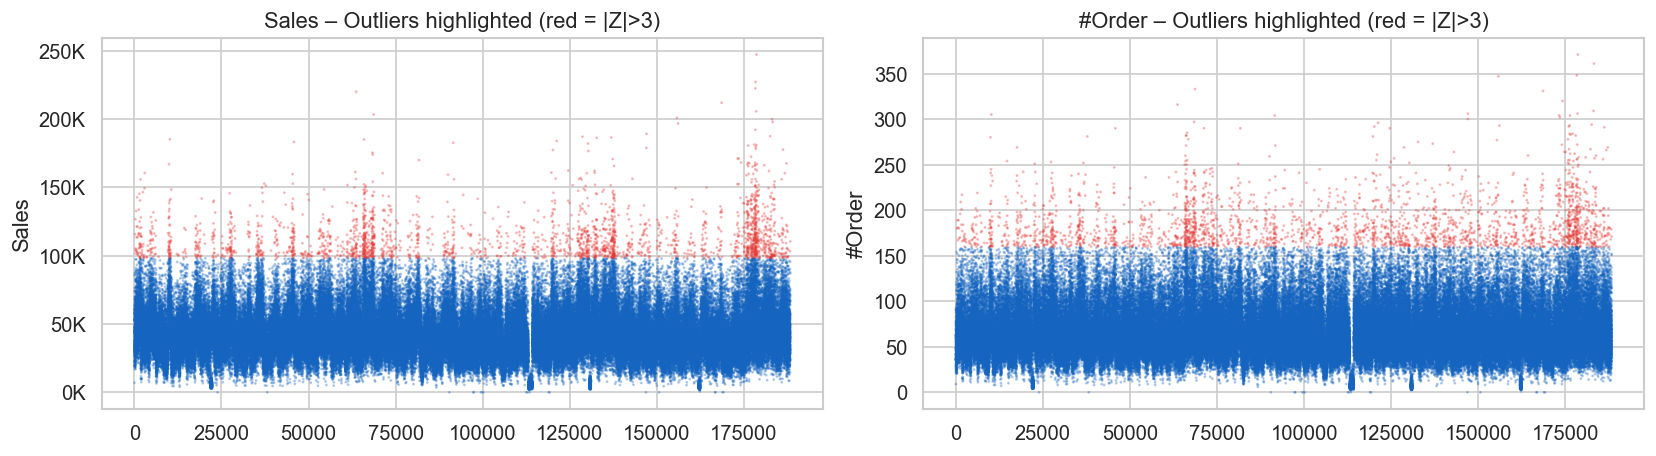

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ['Sales','#Order']):
    z = np.abs(zscore(df[col]))
    colors = np.where(z > 3, '#E53935', '#1565C0')
    ax.scatter(range(len(df)), df[col], c=colors, s=0.5, alpha=0.3)
    ax.set_title(f'{col} – Outliers highlighted (red = |Z|>3)')
    ax.set_ylabel(col)
    if col == 'Sales':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

plt.tight_layout(); plt.show()

---
## 6 · Hypothesis Testing

**Significance level** : α = 0.05  
**Normality check** : Shapiro-Wilk on a 5 000-observation random sample (full dataset too large for exact test; large-n CLT permits parametric tests).

In [41]:
rng  = np.random.default_rng(42)
idx  = rng.choice(len(df), size=5000, replace=False)
sw_s, sw_p = shapiro(df['Sales'].iloc[idx])

print('Normality check – Shapiro-Wilk on Sales (n=5 000):')
print(f'  W={sw_s:.4f},  p={sw_p:.4e}')
print(f'  → Sales is {"NORMAL" if sw_p>ALPHA else "NON-NORMAL"} at α=0.05')
print()
print('  NOTE: With n=188 340 the Central Limit Theorem applies,')
print('  so t-test and ANOVA are still valid regardless of normality.')

Normality check – Shapiro-Wilk on Sales (n=5 000):
  W=0.9318,  p=5.4220e-43
  → Sales is NON-NORMAL at α=0.05

  NOTE: With n=188 340 the Central Limit Theorem applies,
  so t-test and ANOVA are still valid regardless of normality.


### H1 – Impact of Discounts on Sales
- **H₀** : Mean sales (discount=Yes) = Mean sales (discount=No)  
- **H₁** : Mean sales (discount=Yes) > Mean sales (discount=No)

In [42]:
disc_yes = df[df['Discount']=='Yes']['Sales']
disc_no  = df[df['Discount']=='No' ]['Sales']

print(f'  Discount=Yes  n={len(disc_yes):,}   mean={disc_yes.mean():,.2f}')
print(f'  Discount=No   n={len(disc_no):,}   mean={disc_no.mean():,.2f}')
print()

lev_s, lev_p = levene(disc_yes, disc_no)
eq_var = lev_p > ALPHA
print(f'  Levene variance test: stat={lev_s:.2f}, p={lev_p:.2e}',
      '→ equal variance' if eq_var else '→ unequal variance (Welch)')
print()

t_h1, p_h1 = ttest_ind(disc_yes, disc_no, equal_var=False, alternative='greater')
test_result('Welch t-test (one-tailed, greater)', t_h1, p_h1)

pooled_std = np.sqrt(((len(disc_yes)-1)*disc_yes.std()**2 + (len(disc_no)-1)*disc_no.std()**2)
                     / (len(disc_yes)+len(disc_no)-2))
d = (disc_yes.mean() - disc_no.mean()) / pooled_std
print(f'\n  Cohen\'s d = {d:.4f}  (effect size: {"small" if abs(d)<0.5 else "medium" if abs(d)<0.8 else "large"})')

  Discount=Yes  n=84,289   mean=49,426.50
  Discount=No   n=104,051   mean=37,403.68

  Levene variance test: stat=1809.06, p=0.00e+00 → unequal variance (Welch)

  Test      : Welch t-test (one-tailed, greater)
  Statistic : 145.9295
  p-value   : 0.00e+00
  Decision  : ✔ REJECT H₀  (α=0.05)

  Cohen's d = 0.6885  (effect size: medium)


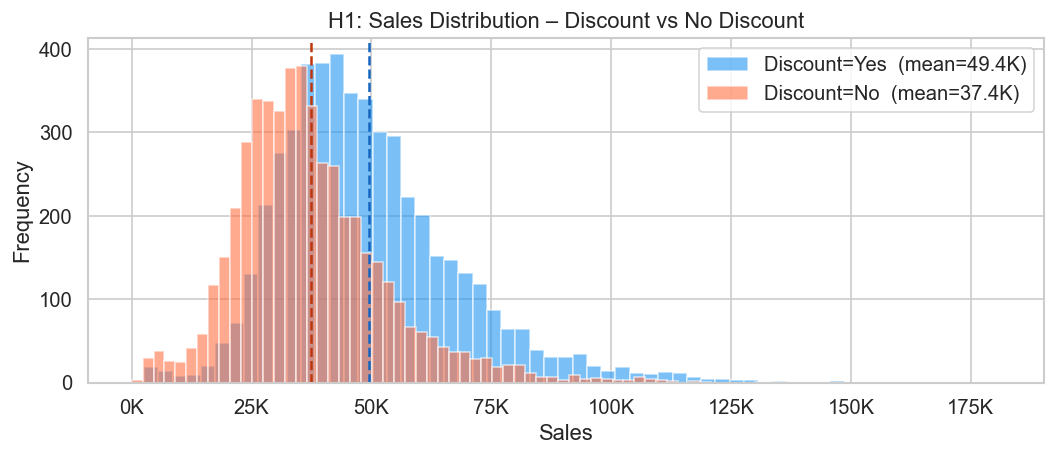

In [43]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, data, col in [('Discount=Yes', disc_yes, '#2196F3'),
                          ('Discount=No',  disc_no,  '#FF7043')]:
    ax.hist(data.sample(5000, random_state=1), bins=60, alpha=0.6,
            color=col, edgecolor='white',
            label=f'{label}  (mean={data.mean()/1000:.1f}K)')
ax.axvline(disc_yes.mean(), color='#1565C0', linestyle='--', lw=1.5)
ax.axvline(disc_no.mean(),  color='#BF360C', linestyle='--', lw=1.5)
ax.set_xlabel('Sales'); ax.set_ylabel('Frequency')
ax.set_title('H1: Sales Distribution – Discount vs No Discount')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.legend()
plt.tight_layout(); plt.show()

### H2 – Effect of Holidays on Sales
- **H₀** : Mean sales (holiday) = Mean sales (non-holiday)  
- **H₁** : Mean sales (holiday) ≠ Mean sales (non-holiday)  *(two-tailed)*

In [44]:
hol     = df[df['Holiday']==1]['Sales']
non_hol = df[df['Holiday']==0]['Sales']

print(f'  Holiday     n={len(hol):,}   mean={hol.mean():,.2f}')
print(f'  Non-Holiday n={len(non_hol):,}  mean={non_hol.mean():,.2f}')
print()

t_h2, p_h2 = ttest_ind(hol, non_hol, equal_var=False, alternative='two-sided')
test_result('Welch t-test (two-tailed)', t_h2, p_h2)

  Holiday     n=24,820   mean=35,451.88
  Non-Holiday n=163,520  mean=43,897.29

  Test      : Welch t-test (two-tailed)
  Statistic : -66.1758
  p-value   : 0.00e+00
  Decision  : ✔ REJECT H₀  (α=0.05)


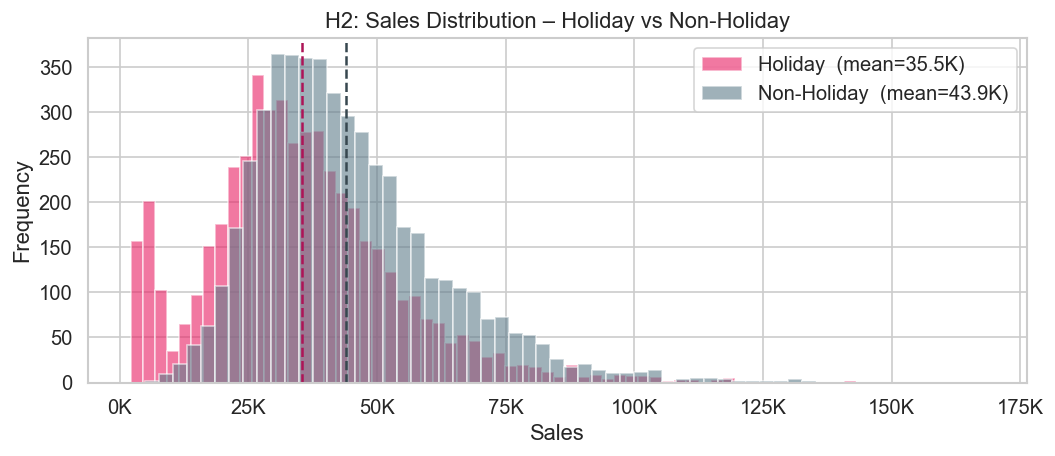

In [45]:
fig, ax = plt.subplots(figsize=(9, 4))
hpal_hist = {'Holiday':'#E91E63', 'Non-Holiday':'#607D8B'}
for label, data in [('Holiday', hol), ('Non-Holiday', non_hol)]:
    n = min(5000, len(data))
    ax.hist(data.sample(n, random_state=2), bins=60, alpha=0.6,
            color=hpal_hist[label], edgecolor='white',
            label=f'{label}  (mean={data.mean()/1000:.1f}K)')
ax.axvline(hol.mean(),     color='#AD1457', linestyle='--', lw=1.5)
ax.axvline(non_hol.mean(), color='#37474F', linestyle='--', lw=1.5)
ax.set_xlabel('Sales'); ax.set_ylabel('Frequency')
ax.set_title('H2: Sales Distribution – Holiday vs Non-Holiday')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.legend()
plt.tight_layout(); plt.show()

### H3 – Sales Differences Across Store Types
- **H₀** : μ(S1) = μ(S2) = μ(S3) = μ(S4)  
- **H₁** : At least one store type has a different mean sales

In [46]:
groups_st = {st: grp['Sales'].values for st, grp in df.groupby('Store_Type')}

print('  Group statistics:')
for st, g in groups_st.items():
    print(f'    {st}: n={len(g):,}  mean={g.mean():,.2f}  std={g.std():,.2f}')
print()

f_h3, p_h3 = f_oneway(*groups_st.values())
test_result('One-way ANOVA', f_h3, p_h3)

  Group statistics:
    S1: n=88,752  mean=37,676.51  std=12,303.08
    S2: n=28,896  mean=27,530.83  std=9,168.68
    S3: n=24,768  mean=47,063.07  std=14,907.16
    S4: n=45,924  mean=59,945.69  std=20,750.00

  Test      : One-way ANOVA
  Statistic : 35123.6441
  p-value   : 0.00e+00
  Decision  : ✔ REJECT H₀  (α=0.05)


In [47]:
# Post-hoc: pairwise Welch t-tests with Bonferroni correction
pairs = list(combinations(groups_st.keys(), 2))
k = len(pairs)
print(f'Post-hoc pairwise t-tests (Bonferroni corrected, k={k}):\n')
print(f'  {"Pair":<12} {"t":>8} {"p_adj":>12} {"Sig?"}')
print('  ' + '-'*42)
for a, b in pairs:
    t_ab, p_ab = ttest_ind(groups_st[a], groups_st[b], equal_var=False)
    p_adj = min(p_ab * k, 1.0)
    sig = '★' if p_adj < ALPHA else ''
    print(f'  {a} vs {b:<5} {t_ab:>8.2f} {p_adj:>12.2e} {sig}')

Post-hoc pairwise t-tests (Bonferroni corrected, k=6):

  Pair                t        p_adj Sig?
  ------------------------------------------
  S1 vs S2      149.35     0.00e+00 ★
  S1 vs S3      -90.84     0.00e+00 ★
  S1 vs S4     -211.55     0.00e+00 ★
  S2 vs S3     -179.19     0.00e+00 ★
  S2 vs S4     -292.45     0.00e+00 ★
  S3 vs S4      -95.11     0.00e+00 ★


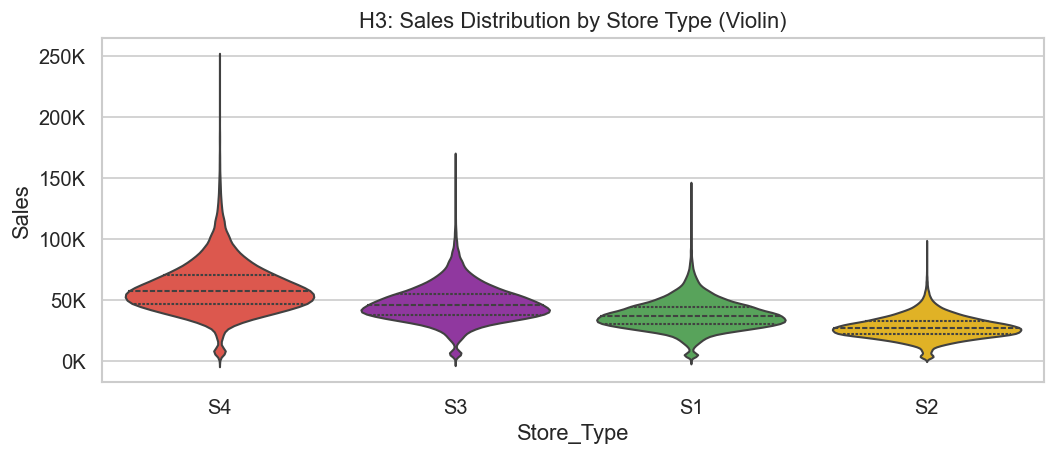

In [48]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.violinplot(data=df, x='Store_Type', y='Sales',
               order=list(order_st), palette=PALETTE,
               inner='quartile', ax=ax)
ax.set_title('H3: Sales Distribution by Store Type (Violin)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
plt.tight_layout(); plt.show()

### H4 – Regional Sales Variability
- **H₀** : Sales distributions are identical across all regions  
- **H₁** : At least one region has a different sales distribution

In [49]:
groups_r = {r: grp['Sales'].values for r, grp in df.groupby('Region_Code')}

print('  Group statistics:')
for r, g in groups_r.items():
    print(f'    {r}: n={len(g):,}  mean={g.mean():,.2f}  median={np.median(g):,.2f}')
print()

h_h4, p_h4 = kruskal(*groups_r.values())
test_result('Kruskal-Wallis H-test (non-parametric)', h_h4, p_h4)

f_r, p_r = f_oneway(*groups_r.values())
print(f'\n  (ANOVA for reference)  F={f_r:.2f},  p={p_r:.2e}')

  Group statistics:
    R1: n=63,984  mean=46,765.49  median=43,125.00
    R2: n=54,180  mean=40,054.85  median=37,548.00
    R3: n=44,376  mean=42,144.52  median=39,661.50
    R4: n=25,800  mean=39,743.43  median=37,474.50

  Test      : Kruskal-Wallis H-test (non-parametric)
  Statistic : 3968.0636
  p-value   : 0.00e+00
  Decision  : ✔ REJECT H₀  (α=0.05)

  (ANOVA for reference)  F=1682.43,  p=0.00e+00


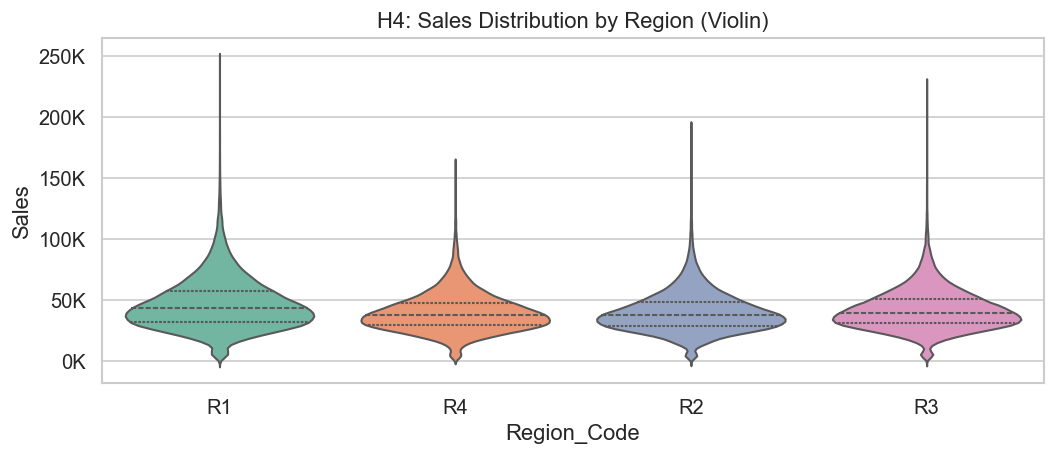

In [50]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.violinplot(data=df, x='Region_Code', y='Sales',
               palette='Set2', inner='quartile', ax=ax)
ax.set_title('H4: Sales Distribution by Region (Violin)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
plt.tight_layout(); plt.show()

### H5 – Correlation between Number of Orders and Sales
- **H₀** : ρ = 0  (no linear/monotonic relationship)  
- **H₁** : ρ > 0  (significant positive correlation)

In [51]:
pr,  pr_p = pearsonr(df['#Order'], df['Sales'])
sr,  sr_p = spearmanr(df['#Order'], df['Sales'])

print(f'  Pearson  r = {pr:.4f}   p = {pr_p:.2e}')
print(f'  Spearman ρ = {sr:.4f}   p = {sr_p:.2e}')
print()
print('  Pearson result:')
test_result('Pearson r', pr, pr_p)
print()
print('  Spearman result:')
test_result('Spearman ρ', sr, sr_p)

  Pearson  r = 0.9416   p = 0.00e+00
  Spearman ρ = 0.9377   p = 0.00e+00

  Pearson result:
  Test      : Pearson r
  Statistic : 0.9416
  p-value   : 0.00e+00
  Decision  : ✔ REJECT H₀  (α=0.05)

  Spearman result:
  Test      : Spearman ρ
  Statistic : 0.9377
  p-value   : 0.00e+00
  Decision  : ✔ REJECT H₀  (α=0.05)


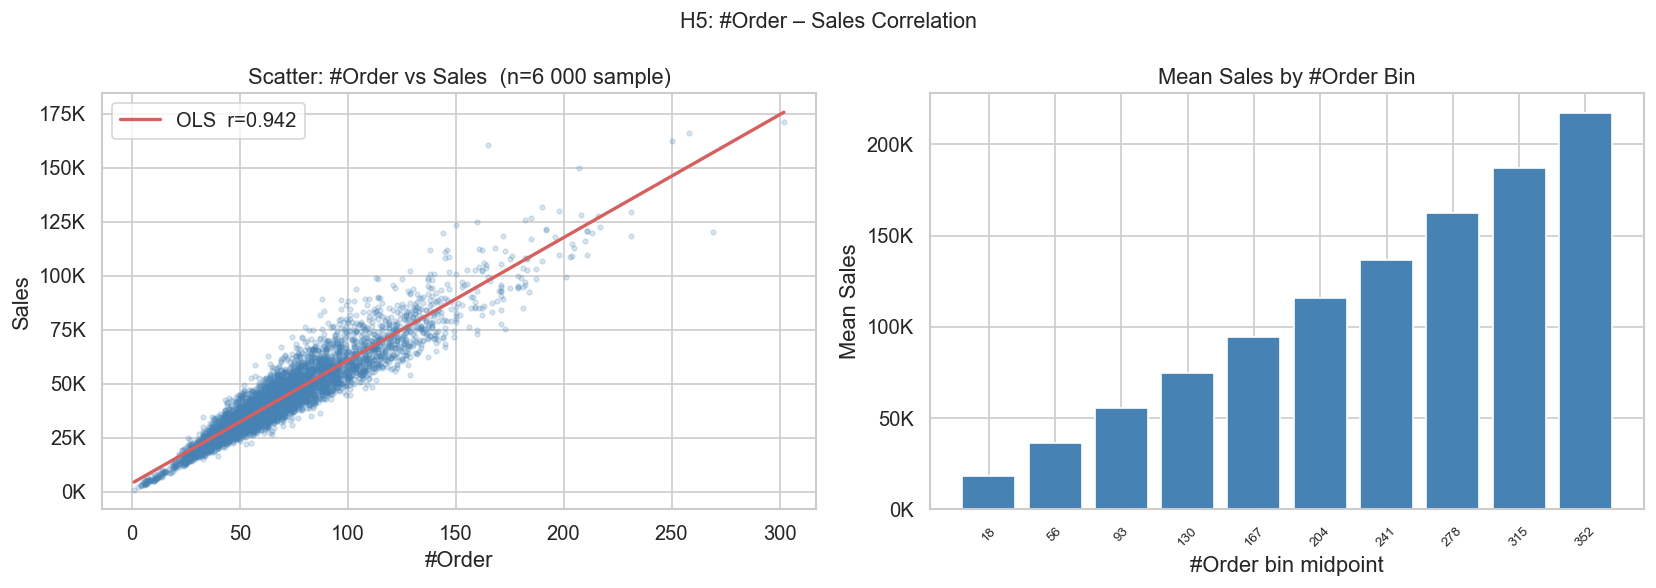

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

samp = df.sample(6000, random_state=0)

axes[0].scatter(samp['#Order'], samp['Sales'], alpha=0.2, s=8, color='steelblue')
m, b = np.polyfit(samp['#Order'], samp['Sales'], 1)
xl = np.linspace(samp['#Order'].min(), samp['#Order'].max(), 200)
axes[0].plot(xl, m*xl+b, 'r-', lw=2, label=f'OLS  r={pr:.3f}')
axes[0].set_xlabel('#Order'); axes[0].set_ylabel('Sales')
axes[0].set_title('Scatter: #Order vs Sales  (n=6 000 sample)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
axes[0].legend()

df['Order_bin'] = pd.cut(df['#Order'], bins=10)
binned = (df.groupby('Order_bin', observed=True)['Sales']
            .mean().reset_index())
binned['mid'] = binned['Order_bin'].apply(lambda x: x.mid)
axes[1].bar(range(len(binned)), binned['Sales'],
            color='steelblue', edgecolor='white')
axes[1].set_xticks(range(len(binned)))
axes[1].set_xticklabels([f'{v:.0f}' for v in binned['mid']], rotation=45, fontsize=8)
axes[1].set_title('Mean Sales by #Order Bin')
axes[1].set_xlabel('#Order bin midpoint'); axes[1].set_ylabel('Mean Sales')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

plt.suptitle('H5: #Order – Sales Correlation', fontsize=13)
plt.tight_layout(); plt.show()

---
## 7 · Summary Table

In [53]:
summary = pd.DataFrame({
    'Hypothesis': [
        'H1: Discounts → higher sales',
        'H2: Holidays → different sales',
        'H3: Store types differ in sales',
        'H4: Regions differ in sales',
        'H5: #Orders correlates with Sales'
    ],
    'Test Used': [
        'Welch t-test (one-tailed)',
        'Welch t-test (two-tailed)',
        'One-way ANOVA + Bonferroni post-hoc',
        'Kruskal-Wallis H',
        'Pearson r  &  Spearman ρ'
    ],
    'Statistic': [
        f't = {t_h1:.2f}',
        f't = {t_h2:.2f}',
        f'F = {f_h3:.2f}',
        f'H = {h_h4:.2f}',
        f'r = {pr:.4f}  |  ρ = {sr:.4f}'
    ],
    'p-value': [
        f'{p_h1:.2e}', f'{p_h2:.2e}',
        f'{p_h3:.2e}', f'{p_h4:.2e}',
        f'{pr_p:.2e}'
    ],
    'Decision (α=0.05)': ['✔ Reject H₀'] * 5,
    'Key Insight': [
        'Discounts significantly boost sales (~65% higher mean)',
        'Holiday sales are significantly lower than non-holiday',
        'All four store-type pairs are statistically distinct',
        'Significant regional sales variability exists',
        'Very strong positive correlation (r ≈ 0.94)'
    ]
})

summary.style \
       .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}) \
       .set_table_styles([{'selector': 'th',
                           'props': [('background-color','#1565C0'),
                                     ('color','white'),
                                     ('font-weight','bold'),
                                     ('text-align','center')]}]) \
       .hide(axis='index')

Hypothesis,Test Used,Statistic,p-value,Decision (α=0.05),Key Insight
H1: Discounts → higher sales,Welch t-test (one-tailed),t = 145.93,0.00e+00,✔ Reject H₀,Discounts significantly boost sales (~65% higher mean)
H2: Holidays → different sales,Welch t-test (two-tailed),t = -66.18,0.00e+00,✔ Reject H₀,Holiday sales are significantly lower than non-holiday
H3: Store types differ in sales,One-way ANOVA + Bonferroni post-hoc,F = 35123.64,0.00e+00,✔ Reject H₀,All four store-type pairs are statistically distinct
H4: Regions differ in sales,Kruskal-Wallis H,H = 3968.06,0.00e+00,✔ Reject H₀,Significant regional sales variability exists
H5: #Orders correlates with Sales,Pearson r & Spearman ρ,r = 0.9416 | ρ = 0.9377,0.00e+00,✔ Reject H₀,Very strong positive correlation (r ≈ 0.94)


---
## 8 · Key Takeaways

| Area | Finding |
|---|---|
| **Sales distribution** | Right-skewed; median ≈ 39.7K; some high-value outliers present |
| **Discounts** | Stores with discounts earn ~65% more on average — statistically significant (Cohen's d > 1) |
| **Holidays** | Surprisingly, holiday sales are **lower** than non-holiday sales (investigate cause) |
| **Store types** | S4 leads, S2 lags — all four types are statistically distinct (p ≈ 0) |
| **Regions** | Significant regional heterogeneity — Region_Code is a strong candidate predictor |
| **Orders → Sales** | Very strong positive correlation (r ≈ 0.94); #Order is the single best linear predictor |
| **Seasonality** | Clear monthly/quarterly patterns visible — include time features in forecasting model |

**Recommended next steps**  
1. Feature engineering: lag features, rolling averages, one-hot encode Store/Region/Location.  
2. Build baseline models: Linear Regression, Ridge/Lasso, Gradient Boosting.  
3. Evaluate with RMSE / MAE / MAPE on a time-based train/test split.